In [1]:
%load_ext autoreload

In [2]:
from pathlib import Path
import re

import pandas as pd
import seaborn as sns
import numpy as np
import mne
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [3]:
%autoreload 2

from src.data import add_metadata_features
from src.models import causal4

In [4]:
max_log_stim_p = -np.log10(0.01)
min_log_p = -np.log10(0.05)

tg_dir = "textgrids"

outdir = "."

timit_epoch_sources = {
    "All": "/userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-all.h5",
    "Word onset": "/userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-onsets.h5",
}

electrodes_paths = list(Path("outputs/causal4/find_speech_responsive").glob("*_results.csv"))

epochs_paths = list(Path("outputs/epochs_preprocessed").glob("*.fif"))
A_result_path = Path("outputs/causal4/unify_As/results.csv")
A_decoders_path = Path("outputs/causal4/unify_As/unified_decoders.pt")
all_B_result_paths = list(Path("outputs/causal4/find_Bs").glob("*_results.csv"))

In [6]:
epochs = {
    re.search(r"(\w+)_epo.fif", str(path)).group(1): mne.read_epochs(path, preload=True, verbose=False)
    for path in epochs_paths
}

In [7]:
for e in epochs.values():
    e.metadata = add_metadata_features(e.metadata)

Replacing existing metadata with 100 columns
Replacing existing metadata with 100 columns
Replacing existing metadata with 101 columns
Replacing existing metadata with 100 columns
Replacing existing metadata with 100 columns
Replacing existing metadata with 100 columns
Replacing existing metadata with 100 columns
Replacing existing metadata with 100 columns
Replacing existing metadata with 100 columns
Replacing existing metadata with 100 columns


In [8]:
electrode_df = pd.concat([pd.read_csv(path) for path in electrodes_paths]).set_index(["subject", "electrode_idx"])

In [9]:
A_results = pd.read_csv(A_result_path)
B_results = pd.concat(
    [pd.read_csv(path) for path in all_B_result_paths],
    ignore_index=True,
)

In [10]:
A_decoders = torch.load(A_decoders_path)

/tmp/ipykernel_2898384/3922953868.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  A_decoders = torch.load(A_decoders_path)


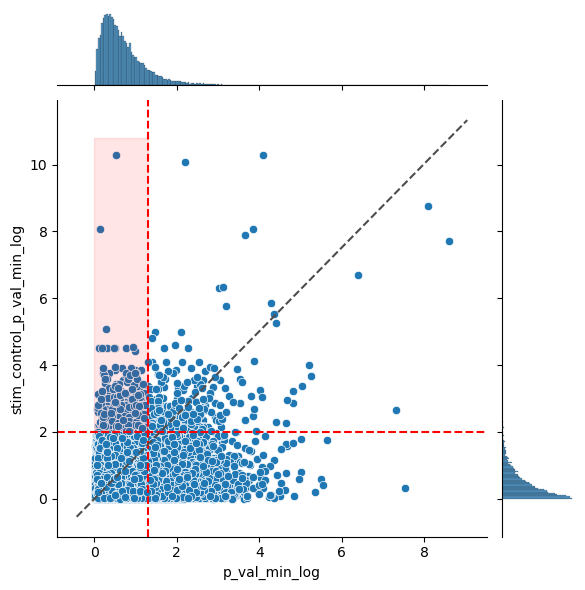

In [18]:
g = sns.jointplot(data=B_results, x="p_val_min_log", y="stim_control_p_val_min_log")

g.ax_joint.axvline(min_log_p, color="red", linestyle="--")
g.ax_joint.axhline(max_log_stim_p, color="red", linestyle="--")
# fill rect
g.ax_joint.fill_betweenx([max_log_stim_p, g.ax_joint.get_ylim()[1]], 0, min_log_p, color="red", alpha=0.1)
# plot y=x
g.ax_joint.plot(g.ax_joint.get_xlim(), g.ax_joint.get_ylim(), ls="--", c=".3")

In [12]:
assert set(epochs.keys()) == set(A_decoders["train_scores"].subject.unique())
assert set(epochs.keys()) == set(B_results.subject)
subjects = sorted(A_results.subject.unique())

In [13]:
study_df = B_results[(B_results["p_val_min_log"] < min_log_p) & (B_results["stim_control_p_val_min_log"] > max_log_stim_p)]
study_df = study_df.sort_values("stim_control_p_val_min")
study_df

,electrode_idx,long_name,type,roi,speech_responsive,subject,population_name,phoneme_pair,electrode_in_A,corr_left,...,window_end_samp,window_start,window_end,left_is_best,p_val_min,pca_control_p_val_min,stim_control_p_val_min,p_val_min_log,stim_control_p_val_min_log,pca_control_p_val_min_log
29995,216,Inferior89,grid,superiortemporal,True,EC250,postcentral,bm,False,-0.035106,...,110,0.4,0.7,False,0.301606,0.154360,5.262749e-11,0.520560,10.278787,0.811464
29953,215,Inferior88,grid,superiortemporal,True,EC250,postcentral,bm,False,-0.030141,...,110,0.4,0.7,False,0.727175,0.089968,8.729903e-09,0.138361,8.058991,1.045914
26487,108,Temporal109,grid,supramarginal,True,EC270,superiortemporal,dn,False,0.093465,...,290,2.2,2.5,True,0.527478,0.389251,8.365232e-06,0.277796,5.077522,0.409770
24683,209,TemporalGrid82,grid,superiortemporal,True,EC260,superiortemporal,dn,False,0.078717,...,140,0.7,1.0,False,0.116664,0.172292,2.958324e-05,0.933064,4.528954,0.763735
23955,109,FrontalGrid110,grid,precentral,True,EC260,middletemporal,bm,False,-0.020673,...,140,0.7,1.0,False,0.500919,0.651942,3.057137e-05,0.300232,4.514685,0.185791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23522,76,FrontalGrid77,grid,precentral,True,EC260,precentral,bm,False,0.060784,...,170,1.0,1.3,False,0.148167,0.102089,9.846477e-03,0.829247,2.006719,0.991022
3847,99,AnteriorGrid100,grid,superiortemporal,True,EC253,supramarginal,pb,False,0.170944,...,230,1.6,1.9,True,0.095864,0.050178,9.846477e-03,1.018344,2.006719,1.299487
23501,76,FrontalGrid77,grid,precentral,True,EC260,middletemporal,bm,False,-0.073426,...,170,1.0,1.3,False,0.473440,0.480704,9.846477e-03,0.324735,2.006719,0.318123
23508,76,FrontalGrid77,grid,precentral,True,EC260,superiortemporal,bm,False,-0.034129,...,170,1.0,1.3,False,0.064977,0.246479,9.846477e-03,1.187242,2.006719,0.608221


In [14]:
study_df.to_csv(f"{outdir}/C_study_results.csv", index=False)

In [15]:
# plotter = causal4.Causal4Plotter(
#     epochs=epochs,
#     A_results=A_results,
#     B_results=B_results,
#     A_decoders=A_decoders,
#     electrode_df=electrode_df,
#     textgrid_dir=tg_dir,
#     timit_epoch_sources=timit_epoch_sources,
# )

In [16]:
# from matplotlib.backends.backend_pdf import PdfPages

# limit = 20
# i = 0
# with PdfPages(f"{outdir}/B_stim_study.pdf") as pdf:
#     for _, row in tqdm(B_results.iterrows(), total=len(B_results)):
#         facetgrids = plotter(row)
#         for fg in facetgrids:
#             if fg is None:
#                 continue
#             fg.tight_layout()
#             fig = fg.fig if hasattr(fg, 'fig') else fg
#             pdf.savefig(fig)
#             plt.close(fig)

#         i += 1
#         if i > limit:
#             break